In [8]:
from pathlib import Path
municipios_path = Path(r"D:\Arq-Azzoni\UrbanSprawl\Bases_dados\Shapes\BR_Municipios_2024\BR_Municipios_2024.shp")

ANNUAL DIFF | 2022 - 2000
mean   : 0.048177935
median : 0.047765017
min    : -0.99361944
max    : 0.9770921
Saved figure: D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\plots\jundiai_diff_2022_2000_ndvi.png


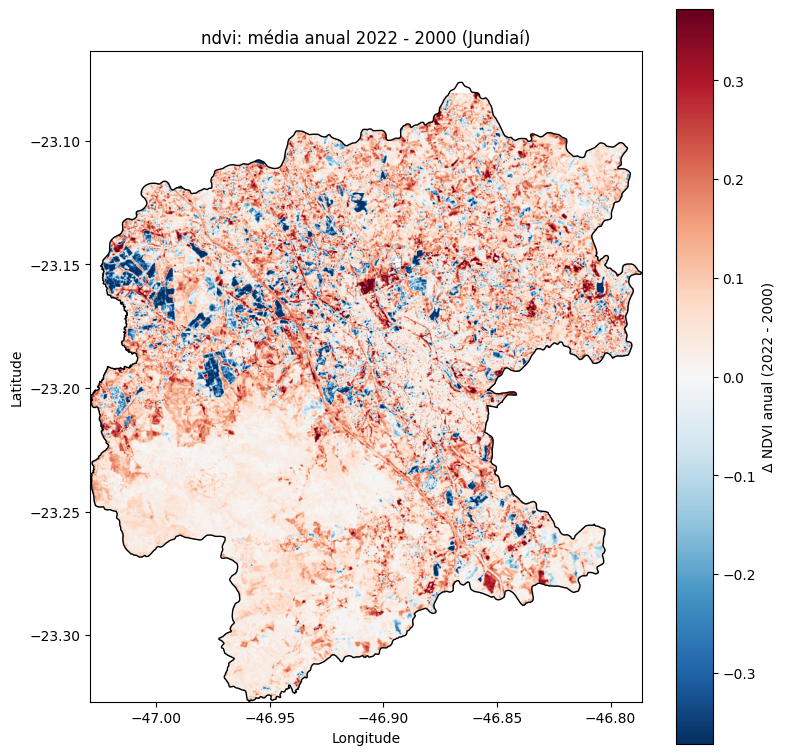

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from pathlib import Path

# =====================================
# 1) PATHS
# =====================================
base = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\annual")
municipios_path = Path(r"D:\Arq-Azzoni\UrbanSprawl\Bases_dados\Shapes\BR_Municipios_2024\BR_Municipios_2024.shp")

rasters = {
    "2000": base / "jundiai_2000_annual_mean_ndvi_temp.tif",
    "2022": base / "jundiai_2022_annual_mean_ndvi_temp.tif",
}

# =====================================
# 2) FUNCTIONS
# =====================================
def read_band_by_description(src, band_name):
    desc = list(src.descriptions)
    if band_name not in desc:
        raise ValueError(f"Banda '{band_name}' não encontrada em {src.name}. Bandas: {desc}")
    return desc.index(band_name) + 1

def clip_band_to_polygon(raster_path, polygon_gdf, band_name="tempC"):
    with rasterio.open(raster_path) as src:
        band_idx = read_band_by_description(src, band_name)

        poly = polygon_gdf.to_crs(src.crs)
        geoms = [geom.__geo_interface__ for geom in poly.geometry]

        clipped, transform = mask(src, geoms, crop=True, filled=True, indexes=band_idx)

        arr = clipped.astype("float32")
        if arr.ndim == 3:
            arr = arr[0]

        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan

        h, w = arr.shape
        left = transform.c
        top = transform.f
        right = left + transform.a * w
        bottom = top + transform.e * h
        extent = [left, right, bottom, top]

        return arr, extent, src.crs

# =====================================
# 3) READ JUNDIAÍ SHAPE
# =====================================
jundiai = gpd.read_file(municipios_path)
jundiai = jundiai[jundiai["CD_MUN"].astype(str) == "3525904"].copy()

if jundiai.empty:
    raise ValueError("Não encontrei Jundiaí com CD_MUN = 3525904.")

# =====================================
# 4) CHOOSE BAND
# =====================================
#band_name = "tempC"   # troque para "ndvi" se quiser

band_name = "ndvi"  

colorbar_label = (
    "Δ tempC anual (2022 - 2000)"
    if band_name == "tempC"
    else "Δ NDVI anual (2022 - 2000)"
)

# =====================================
# 5) READ, CLIP, DIFFERENCE
# =====================================
arr_2000, extent, crs = clip_band_to_polygon(rasters["2000"], jundiai, band_name=band_name)
arr_2022, _, _ = clip_band_to_polygon(rasters["2022"], jundiai, band_name=band_name)

if arr_2000.shape != arr_2022.shape:
    raise ValueError(f"Shapes diferentes: {arr_2000.shape} vs {arr_2022.shape}")

diff = arr_2022 - arr_2000

# escala simétrica
vmax = np.nanpercentile(np.abs(diff), 98)

# =====================================
# 6) STATS
# =====================================
print("ANNUAL DIFF | 2022 - 2000")
print("mean   :", np.nanmean(diff))
print("median :", np.nanmedian(diff))
print("min    :", np.nanmin(diff))
print("max    :", np.nanmax(diff))

# =====================================
# 7) PLOT
# =====================================
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    np.ma.masked_invalid(diff),
    extent=extent,
    origin="upper",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax
)

jundiai.to_crs(crs).boundary.plot(ax=ax, color="black", linewidth=1)

ax.set_title(f"{band_name}: média anual 2022 - 2000 (Jundiaí)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label=colorbar_label)
plt.tight_layout()
plots = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\plots")
out_png = plots / f"jundiai_diff_2022_2000_{band_name}.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"Saved figure: {out_png}")

plt.show()

In [ ]:
from pathlib import Path

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.io import MemoryFile
from rasterio.transform import array_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling

import folium
import branca.colormap as bcm
from matplotlib import cm, colors

# =====================================
# 1) PATHS
# =====================================
base = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\annual")
#municipios_path = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\shapes\municipios_sp.shp")

rasters = {
    "2000": base / "jundiai_2000_annual_mean_ndvi_temp.tif",
    "2022": base / "jundiai_2022_annual_mean_ndvi_temp.tif",
}

# =====================================
# 2) LER POLÍGONO DE JUNDIAÍ
# =====================================
jundiai = gpd.read_file(municipios_path)
jundiai = jundiai[jundiai["CD_MUN"].astype(str) == "3525904"].copy()

if jundiai.empty:
    raise ValueError("Não encontrei Jundiaí com CD_MUN = 3525904.")

# =====================================
# 3) FUNÇÕES
# =====================================
def read_band_by_description(src, band_name):
    desc = list(src.descriptions)
    if band_name not in desc:
        raise ValueError(f"Banda '{band_name}' não encontrada em {src.name}. Bandas: {desc}")
    return desc.index(band_name) + 1


def clip_band_to_polygon(raster_path, polygon_gdf, band_name):
    with rasterio.open(raster_path) as src:
        band_idx = read_band_by_description(src, band_name)

        poly = polygon_gdf.to_crs(src.crs)
        geoms = [geom.__geo_interface__ for geom in poly.geometry]

        clipped, transform = mask(
            src,
            geoms,
            crop=True,
            filled=True,
            indexes=band_idx
        )

        arr = clipped.astype("float32")
        if arr.ndim == 3:
            arr = arr[0]

        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan

        return arr, transform, src.crs


def reproject_array_to_wgs84(arr, transform, src_crs):
    """
    Reprojeta um array 2D para EPSG:4326, preservando NaN.
    """
    h, w = arr.shape

    left, bottom, right, top = array_bounds(h, w, transform)

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, "EPSG:4326", w, h, left, bottom, right, top
    )

    dst_arr = np.full((dst_height, dst_width), np.nan, dtype="float32")

    reproject(
        source=arr,
        destination=dst_arr,
        src_transform=transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs="EPSG:4326",
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=Resampling.nearest
    )

    return dst_arr, dst_transform


def make_rgba_overlay(arr, cmap_name="RdYlGn", symmetric=False, vmin=None, vmax=None, alpha=0.65):
    """
    Converte array 2D em imagem RGBA para overlay no folium.
    """
    valid = arr[np.isfinite(arr)]
    if valid.size == 0:
        raise ValueError("Array sem valores válidos para plotar.")

    if vmin is None or vmax is None:
        if symmetric:
            vmax_auto = np.nanpercentile(np.abs(valid), 98)
            vmin = -vmax_auto
            vmax = vmax_auto
        else:
            vmin = np.nanpercentile(valid, 2)
            vmax = np.nanpercentile(valid, 98)

    norm = colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap = cm.get_cmap(cmap_name)

    rgba = cmap(norm(arr))  # retorna float 0-1
    rgba[..., 3] = np.where(np.isfinite(arr), alpha, 0.0)  # transparência só onde tem dado
    rgba_uint8 = (rgba * 255).astype("uint8")

    return rgba_uint8, vmin, vmax


def transform_to_bounds(transform, shape):
    """
    Retorna bounds no formato [[south, west], [north, east]]
    para ImageOverlay do folium.
    """
    h, w = shape
    left, bottom, right, top = array_bounds(h, w, transform)
    return [[bottom, left], [top, right]]


# =====================================
# 4) LER 2000 E 2022 E CALCULAR DIFERENÇAS
# =====================================
ndvi_2000, transform_ndvi, crs_ndvi = clip_band_to_polygon(rasters["2000"], jundiai, "ndvi")
ndvi_2022, _, _ = clip_band_to_polygon(rasters["2022"], jundiai, "ndvi")

temp_2000, transform_temp, crs_temp = clip_band_to_polygon(rasters["2000"], jundiai, "tempC")
temp_2022, _, _ = clip_band_to_polygon(rasters["2022"], jundiai, "tempC")

if ndvi_2000.shape != ndvi_2022.shape:
    raise ValueError(f"NDVI com shapes diferentes: {ndvi_2000.shape} vs {ndvi_2022.shape}")

if temp_2000.shape != temp_2022.shape:
    raise ValueError(f"tempC com shapes diferentes: {temp_2000.shape} vs {temp_2022.shape}")

diff_ndvi = ndvi_2022 - ndvi_2000
diff_temp = temp_2022 - temp_2000

print("NDVI Δ mean:", np.nanmean(diff_ndvi))
print("tempC Δ mean:", np.nanmean(diff_temp))

# =====================================
# 5) REPROJETAR PARA EPSG:4326
# =====================================
diff_ndvi_wgs84, transform_ndvi_wgs84 = reproject_array_to_wgs84(diff_ndvi, transform_ndvi, crs_ndvi)
diff_temp_wgs84, transform_temp_wgs84 = reproject_array_to_wgs84(diff_temp, transform_temp, crs_temp)

# =====================================
# 6) CRIAR OVERLAYS COLORIDOS
# =====================================
# NDVI: verde = ganho, vermelho = perda
rgba_ndvi, ndvi_vmin, ndvi_vmax = make_rgba_overlay(
    diff_ndvi_wgs84,
    cmap_name="RdYlGn",
    symmetric=True,
    alpha=0.35
)

# Temperatura: vermelho = aqueceu, azul = esfriou
rgba_temp, temp_vmin, temp_vmax = make_rgba_overlay(
    diff_temp_wgs84,
    cmap_name="RdBu_r",
    symmetric=True,
    alpha=0.35
)

bounds_ndvi = transform_to_bounds(transform_ndvi_wgs84, diff_ndvi_wgs84.shape)
bounds_temp = transform_to_bounds(transform_temp_wgs84, diff_temp_wgs84.shape)

# =====================================
# 7) POLÍGONO EM WGS84 PARA O FOLIUM
# =====================================
jundiai_wgs84 = jundiai.to_crs("EPSG:4326")
centroid = jundiai_wgs84.geometry.unary_union.centroid

# =====================================
# 8) MAPA BASE
# =====================================
m = folium.Map(
    location=[centroid.y, centroid.x],
    zoom_start=11,
    tiles=None
)

# Esri World Imagery
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri WorldImagery",
    name="Esri World Imagery",
    overlay=False,
    control=True
).add_to(m)

# alternativa opcional de mapa claro
folium.TileLayer(
    "CartoDB positron",
    name="CartoDB Positron",
    overlay=False,
    control=True
).add_to(m)

# =====================================
# 9) OVERLAYS
# =====================================
folium.raster_layers.ImageOverlay(
    image=rgba_ndvi,
    bounds=bounds_ndvi,
    name="ΔNDVI (2022 - 2000)",
    opacity=1.0,
    interactive=True,
    cross_origin=False
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=rgba_temp,
    bounds=bounds_temp,
    name="ΔtempC (2022 - 2000)",
    opacity=1.0,
    interactive=True,
    cross_origin=False
).add_to(m)

# contorno do município
folium.GeoJson(
    jundiai_wgs84,
    name="Limite Jundiaí",
    style_function=lambda x: {
        "color": "black",
        "weight": 2,
        "fillOpacity": 0
    }
).add_to(m)

# =====================================
# 10) LEGENDAS
# =====================================
colormap_ndvi = bcm.LinearColormap(
    colors=["#d73027", "#fdae61", "#ffffbf", "#a6d96a", "#1a9850"],
    vmin=ndvi_vmin,
    vmax=ndvi_vmax,
    caption="ΔNDVI (2022 - 2000)"
)
colormap_ndvi.add_to(m)

colormap_temp = bcm.LinearColormap(
    colors=["#2166ac", "#67a9cf", "#f7f7f7", "#ef8a62", "#b2182b"],
    vmin=temp_vmin,
    vmax=temp_vmax,
    caption="ΔtempC (2022 - 2000)"
)
colormap_temp.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# =====================================
# 11) SALVAR
# =====================================
plots = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\plots")

out_html = plots / "jundiai_interactive_ndvi_temp_2022_2000.html"
m.save(out_html)

print(f"Mapa salvo em: {out_html}")



NDVI Δ mean: 0.048177935
tempC Δ mean: -0.30820414


d:\Users\ivan.cavalcanti\AppData\Local\Temp\19\ipykernel_70144\362438655.py:118: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
d:\Users\ivan.cavalcanti\AppData\Local\Temp\19\ipykernel_70144\362438655.py:190: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = jundiai_wgs84.geometry.unary_union.centroid


Mapa salvo em: D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\plots\jundiai_interactive_ndvi_temp_2022_2000_uso.html


In [15]:
a = r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\uso_solo\jundiai_espraiamento_2022_2000.tif"
b = r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\uso_solo\jundiai_uso_solo_2000.tif"

In [17]:
from pathlib import Path

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.transform import array_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling

import folium
import branca.colormap as bcm
from matplotlib import cm, colors


# =====================================
# 1) PATHS
# =====================================
base = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\annual")
#municipios_path = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\shapes\municipios_sp.shp")
plots = Path(r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\plots")

rasters = {
    "2000": base / "jundiai_2000_annual_mean_ndvi_temp.tif",
    "2022": base / "jundiai_2022_annual_mean_ndvi_temp.tif",
    "classe24_2000": b,
    "mudou_para_24": a,
}


# =====================================
# 2) LER POLÍGONO DE JUNDIAÍ
# =====================================
jundiai = gpd.read_file(municipios_path)
jundiai = jundiai[jundiai["CD_MUN"].astype(str) == "3525904"].copy()

if jundiai.empty:
    raise ValueError("Não encontrei Jundiaí com CD_MUN = 3525904.")


# =====================================
# 3) FUNÇÕES
# =====================================
def read_band_by_description(src, band_name):
    desc = list(src.descriptions)
    if band_name not in desc:
        raise ValueError(
            f"Banda '{band_name}' não encontrada em {src.name}. Bandas disponíveis: {desc}"
        )
    return desc.index(band_name) + 1


def clip_band_to_polygon(raster_path, polygon_gdf, band_name):
    """
    Lê uma banda pelo nome (description), recorta pelo polígono
    e retorna array 2D + transform + CRS.
    """
    with rasterio.open(raster_path) as src:
        band_idx = read_band_by_description(src, band_name)

        poly = polygon_gdf.to_crs(src.crs)
        geoms = [geom.__geo_interface__ for geom in poly.geometry]

        clipped, transform = mask(
            src,
            geoms,
            crop=True,
            filled=True,
            indexes=band_idx
        )

        arr = clipped.astype("float32")
        if arr.ndim == 3:
            arr = arr[0]

        nodata = src.nodata
        if nodata is not None:
            if np.isnan(nodata):
                arr[np.isnan(arr)] = np.nan
            else:
                arr[arr == nodata] = np.nan

        return arr, transform, src.crs


def clip_singleband_raster_to_polygon(raster_path, polygon_gdf):
    """
    Lê um raster de 1 banda, recorta pelo polígono
    e retorna array 2D + transform + CRS.
    """
    with rasterio.open(raster_path) as src:
        poly = polygon_gdf.to_crs(src.crs)
        geoms = [geom.__geo_interface__ for geom in poly.geometry]

        clipped, transform = mask(
            src,
            geoms,
            crop=True,
            filled=True,
            indexes=1
        )

        arr = clipped.astype("float32")
        if arr.ndim == 3:
            arr = arr[0]

        nodata = src.nodata
        if nodata is not None:
            if np.isnan(nodata):
                arr[np.isnan(arr)] = np.nan
            else:
                arr[arr == nodata] = np.nan

        return arr, transform, src.crs


def reproject_array_to_wgs84(arr, transform, src_crs):
    """
    Reprojeta um array 2D para EPSG:4326, preservando NaN.
    """
    h, w = arr.shape
    left, bottom, right, top = array_bounds(h, w, transform)

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, "EPSG:4326", w, h, left, bottom, right, top
    )

    dst_arr = np.full((dst_height, dst_width), np.nan, dtype="float32")

    reproject(
        source=arr,
        destination=dst_arr,
        src_transform=transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs="EPSG:4326",
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=Resampling.nearest
    )

    return dst_arr, dst_transform


def make_rgba_overlay(arr, cmap_name="RdYlGn", symmetric=False, vmin=None, vmax=None, alpha=0.65):
    """
    Converte array 2D em imagem RGBA para overlay no folium.
    """
    valid = arr[np.isfinite(arr)]
    if valid.size == 0:
        raise ValueError("Array sem valores válidos para plotar.")

    if vmin is None or vmax is None:
        if symmetric:
            vmax_auto = np.nanpercentile(np.abs(valid), 98)
            vmin = -vmax_auto
            vmax = vmax_auto
        else:
            vmin = np.nanpercentile(valid, 2)
            vmax = np.nanpercentile(valid, 98)

    norm = colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap = cm.get_cmap(cmap_name)

    rgba = cmap(norm(arr))
    rgba[..., 3] = np.where(np.isfinite(arr), alpha, 0.0)
    rgba_uint8 = (rgba * 255).astype("uint8")

    return rgba_uint8, vmin, vmax


def make_binary_red_overlay(arr, alpha=0.75):
    """
    Cria overlay RGBA vermelho para raster binário:
    1 = vermelho
    NaN = transparente
    """
    rgba = np.zeros((arr.shape[0], arr.shape[1], 4), dtype="uint8")

    mask_valid = np.isfinite(arr) & (arr == 1)

    rgba[mask_valid, 0] = 255
    rgba[mask_valid, 1] = 0
    rgba[mask_valid, 2] = 0
    rgba[mask_valid, 3] = int(alpha * 255)

    return rgba


def transform_to_bounds(transform, shape):
    """
    Retorna bounds no formato [[south, west], [north, east]]
    para ImageOverlay do folium.
    """
    h, w = shape
    left, bottom, right, top = array_bounds(h, w, transform)
    return [[bottom, left], [top, right]]


# =====================================
# 4) LER 2000 E 2022 E CALCULAR DIFERENÇAS
# =====================================
ndvi_2000, transform_ndvi, crs_ndvi = clip_band_to_polygon(rasters["2000"], jundiai, "ndvi")
ndvi_2022, _, _ = clip_band_to_polygon(rasters["2022"], jundiai, "ndvi")

temp_2000, transform_temp, crs_temp = clip_band_to_polygon(rasters["2000"], jundiai, "tempC")
temp_2022, _, _ = clip_band_to_polygon(rasters["2022"], jundiai, "tempC")

if ndvi_2000.shape != ndvi_2022.shape:
    raise ValueError(f"NDVI com shapes diferentes: {ndvi_2000.shape} vs {ndvi_2022.shape}")

if temp_2000.shape != temp_2022.shape:
    raise ValueError(f"tempC com shapes diferentes: {temp_2000.shape} vs {temp_2022.shape}")

diff_ndvi = ndvi_2022 - ndvi_2000
diff_temp = temp_2022 - temp_2000

print("NDVI Δ mean:", np.nanmean(diff_ndvi))
print("tempC Δ mean:", np.nanmean(diff_temp))


# =====================================
# 5) LER OS 2 NOVOS TIFFS BINÁRIOS
# =====================================
classe24_2000, transform_c24, crs_c24 = clip_singleband_raster_to_polygon(
    rasters["classe24_2000"], jundiai
)

mudou_para_24, transform_m24, crs_m24 = clip_singleband_raster_to_polygon(
    rasters["mudou_para_24"], jundiai
)

print("Pixels classe 24 em 2000:", np.sum(np.isfinite(classe24_2000) & (classe24_2000 == 1)))
print("Pixels que viraram 24 (2022 - 2000):", np.sum(np.isfinite(mudou_para_24) & (mudou_para_24 == 1)))


# =====================================
# 6) REPROJETAR PARA EPSG:4326
# =====================================
diff_ndvi_wgs84, transform_ndvi_wgs84 = reproject_array_to_wgs84(
    diff_ndvi, transform_ndvi, crs_ndvi
)

diff_temp_wgs84, transform_temp_wgs84 = reproject_array_to_wgs84(
    diff_temp, transform_temp, crs_temp
)

classe24_2000_wgs84, transform_c24_wgs84 = reproject_array_to_wgs84(
    classe24_2000, transform_c24, crs_c24
)

mudou_para_24_wgs84, transform_m24_wgs84 = reproject_array_to_wgs84(
    mudou_para_24, transform_m24, crs_m24
)


# =====================================
# 7) CRIAR OVERLAYS COLORIDOS
# =====================================
# NDVI: verde = ganho, vermelho = perda
rgba_ndvi, ndvi_vmin, ndvi_vmax = make_rgba_overlay(
    diff_ndvi_wgs84,
    cmap_name="RdYlGn",
    symmetric=True,
    alpha=0.35
)

# Temperatura: vermelho = aqueceu, azul = esfriou
rgba_temp, temp_vmin, temp_vmax = make_rgba_overlay(
    diff_temp_wgs84,
    cmap_name="RdBu_r",
    symmetric=True,
    alpha=0.35
)

# Binários: vermelho
rgba_classe24_2000 = make_binary_red_overlay(classe24_2000_wgs84, alpha=0.65)
rgba_mudou_para_24 = make_binary_red_overlay(mudou_para_24_wgs84, alpha=0.85)

bounds_ndvi = transform_to_bounds(transform_ndvi_wgs84, diff_ndvi_wgs84.shape)
bounds_temp = transform_to_bounds(transform_temp_wgs84, diff_temp_wgs84.shape)
bounds_c24 = transform_to_bounds(transform_c24_wgs84, classe24_2000_wgs84.shape)
bounds_m24 = transform_to_bounds(transform_m24_wgs84, mudou_para_24_wgs84.shape)


# =====================================
# 8) POLÍGONO EM WGS84 PARA O FOLIUM
# =====================================
jundiai_wgs84 = jundiai.to_crs("EPSG:4326")
centroid = jundiai_wgs84.geometry.unary_union.centroid


# =====================================
# 9) MAPA BASE
# =====================================
m = folium.Map(
    location=[centroid.y, centroid.x],
    zoom_start=11,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri WorldImagery",
    name="Esri World Imagery",
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    "CartoDB positron",
    name="CartoDB Positron",
    overlay=False,
    control=True
).add_to(m)


# =====================================
# 10) OVERLAYS
# =====================================
folium.raster_layers.ImageOverlay(
    image=rgba_ndvi,
    bounds=bounds_ndvi,
    name="ΔNDVI (2022 - 2000)",
    opacity=1.0,
    interactive=True,
    cross_origin=False
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=rgba_temp,
    bounds=bounds_temp,
    name="ΔtempC (2022 - 2000)",
    opacity=1.0,
    interactive=True,
    cross_origin=False
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=rgba_classe24_2000,
    bounds=bounds_c24,
    name="Classe 24 em 2000",
    opacity=0.7,
    interactive=True,
    cross_origin=False
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=rgba_mudou_para_24,
    bounds=bounds_m24,
    name="Virou classe 24 (2022 - 2000)",
    opacity=0.7,
    interactive=True,
    cross_origin=False
).add_to(m)

folium.GeoJson(
    jundiai_wgs84,
    name="Limite Jundiaí",
    style_function=lambda x: {
        "color": "black",
        "weight": 2,
        "fillOpacity": 0
    }
).add_to(m)


# =====================================
# 11) LEGENDAS
# =====================================
colormap_ndvi = bcm.LinearColormap(
    colors=["#d73027", "#fdae61", "#ffffbf", "#a6d96a", "#1a9850"],
    vmin=ndvi_vmin,
    vmax=ndvi_vmax,
    caption="ΔNDVI (2022 - 2000)"
)
colormap_ndvi.add_to(m)

colormap_temp = bcm.LinearColormap(
    colors=["#2166ac", "#67a9cf", "#f7f7f7", "#ef8a62", "#b2182b"],
    vmin=temp_vmin,
    vmax=temp_vmax,
    caption="ΔtempC (2022 - 2000)"
)
colormap_temp.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)


# =====================================
# 12) SALVAR
# =====================================
out_html = plots / "jundiai_interactive_ndvi_temp_classe24_2022_2000.html"
m.save(out_html)

print(f"Mapa salvo em: {out_html}")

NDVI Δ mean: 0.048177935
tempC Δ mean: -0.30820414
Pixels classe 24 em 2000: 88562
Pixels que viraram 24 (2022 - 2000): 41755


d:\Users\ivan.cavalcanti\AppData\Local\Temp\19\ipykernel_70144\352004434.py:162: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
d:\Users\ivan.cavalcanti\AppData\Local\Temp\19\ipykernel_70144\352004434.py:289: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = jundiai_wgs84.geometry.unary_union.centroid


Mapa salvo em: D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\plots\jundiai_interactive_ndvi_temp_classe24_2022_2000.html
